# COMBINE ANNOTATIONS

In [2]:
import json
import os

from pymongo import MongoClient
from datetime import datetime, timezone
from collections import defaultdict

total_videos = 540


def calculate_iou(box1, box2):
    """Calculate Intersection over Union for two boxes [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0



def make_group(group_id, bbox, confidence) -> dict:
    return {
        "groupId": group_id,
        "bbox": bbox,
        "confidence": confidence
    }
    

def make_annotation(video_index, watched, totalwatchtimes, groups, annotation_frame) -> dict:
    """Create a single video annotation entry."""
    
    timestamp = datetime.now(timezone.utc).isoformat()
    
    return {
        "timestamp": timestamp,
        "videoIndex": video_index,
        "videoFolder": f"videos/clip_{video_index:04d}/",
        "videoWatched": watched,
        "totalWatchTimeMs": totalwatchtimes,
        "numberOfGroups": len(groups),
        "groups": groups,
        "videoInfo": {
            "totalFrames": 50,
            "annotationFrame": annotation_frame,
            "coordinateSystem": "normalized",
            "normalizedWidth": 1920,
            "normalizedHeight": 1080
        }
    }

os.makedirs("annotations", exist_ok=True)
    
MONGO_URI = os.getenv('MONGO_URI', 'mongodb://localhost:27017/')
MONGO_DB = 'video_annotations'
    
client = MongoClient(MONGO_URI)
db = client[MONGO_DB]

annotations_collection = db['annotations']
yes_no_annotations_collection = db['yes_no_annotations']

videoFolder = annotations_collection.aggregate([
    { "$group": { "_id": "$videoFolder" } },
    { "$sort": { "_id": 1 } }
])

video_folders = sorted(set([vid['_id'] for vid in list(videoFolder)]))

root = {"completedAt": datetime.now(timezone.utc).isoformat(),"totalVideos": total_videos,"annotations": []}

for folder in video_folders:

    for frame in [1,21,41]:
    
        ind = int(folder.split("_")[1])
    
        test = annotations_collection.aggregate([
            {
                "$match": {
                    "videoFolder": folder,
                    "videoInfo.annotationFrame": frame
                }
            },
            {
                "$unwind": {
                    "path": "$groups",
                    "preserveNullAndEmptyArrays": False}
            },
            {
                "$project": {
                    "_id": 0,
                    "videoFolder": 1,
                    "annotator_id": 1,
                    "annotationFrame": "$videoInfo.annotationFrame",
                    "bbox": "$groups.bbox",
                    "confidence": "$groups.confidence"
                }
            }
        ])    
        
        data = list(test)
    
        #print(data)

        if data == []:
            root["annotations"].append(make_annotation(ind, 0, 0, [], frame))
            continue
        
        frames = defaultdict(lambda: defaultdict(list))
                
        for item in data:
            frame = item["annotationFrame"]
            annotator = item["annotator_id"]
            frames[frame][annotator].append(item["bbox"])
                
        results = [
            list(annotator_groups.values())
            for frame, annotator_groups in sorted(frames.items())
        ]
    

        #print(results)
        
        confidences = defaultdict(lambda: defaultdict(list))
                
        for item in data:
            frame = item["annotationFrame"]
            annotator = item["annotator_id"]
            confidences[frame][annotator].append(item["confidence"])
                
        conf_results = [
            list(annotator_groups.values())
            for frame, annotator_groups in sorted(confidences.items())
        ]
    
        #print(conf_results)
    
        choices_frame = list(set([dat['annotationFrame'] for dat in data]))
        choices_frame.sort()
    
    
        groups = []
        idx = 0
        for idx_group, annotator_group in enumerate(results[0]):

            
            for idx_box, annotator_box in enumerate(annotator_group):
                #print(annotator_box)
                matched = False
    
                for current_group in groups:
                    #print(current_group)
                    if calculate_iou(annotator_box, current_group['bbox']) > 0.3:
                        matched = True
                        break
            
                if not matched:
                    group = make_group(idx, annotator_box, conf_results[0][idx_group][idx_box])
                    groups.append(group)
                    idx+=1
                    
                    #print(groups)
    
        root["annotations"].append(make_annotation(ind, 0, 0, groups, frame))

filename = "coarse_group/all_annotations.json"
with open(filename, "w", encoding="utf-8") as f:
    json.dump(root, f, indent=4)


# READ SBU ANNOTATIONS to generate GT


In [3]:
# READ SBU ANNOTATIONS to generate GT
import json

with open('coarse_group/all_annotations.json', 'r') as f:
    data = json.load(f)

counter = 15
for annotations in data['annotations']:

    ann_frame = annotations['videoInfo']['annotationFrame']
    idx = annotations['videoIndex']

    #print(idx)
    #print(ann_frame)
    for group in annotations['groups']:
        
        x1, y1, x2, y2 = group['bbox']
        group_label = group['groupId']
        dc  = 1
        lvl = 1
        
        GT_list = [idx, ann_frame, x1, y1, x2, y2, group_label, dc, lvl]
        str_to_be_added = [str(k) for k in GT_list]
        str_to_be_added = (" ".join(str_to_be_added))
        f = open('./gt_sekai_ours_'+str(ann_frame)+'.txt', "a+")
        f.write(str_to_be_added + "\r\n")
        f.close()


# PLOT ANNOTATED DATA

In [1]:
# READ SBU ANNOTATIONS to generate GT
import json
import cv2
from matplotlib.patches import Rectangle
import numpy as np
import os

import matplotlib.pyplot as plt

#with open('annotations/sbu_annotations.json', 'r') as f:
#    data = json.load(f)

os.makedirs("fig_annotations", exist_ok=True)

#os.mkdir()

with open('coarse_group/all_annotations.json', 'r') as f:
    data = json.load(f)


frequencies = np.zeros(100)
avg_score   = []

confidence_colors = [
            (255/255, 0/255, 0/255),       # Red
            (255/255, 165/255, 0/255),     # Orange
            (255/255, 255/255, 0/255),     # Yellow
            (0/255, 255/255, 128/255),     # Lime Green
            (0/255, 128/255, 255/255)      # Teal/Cyan
        ]

max_tam = 0
for idx, annotations in enumerate(data['annotations']):

    
    directory_path = annotations['videoFolder']
    frame = annotations['videoInfo']['annotationFrame']
    img_path = directory_path+str(frame+1).zfill(5)+'.jpeg'

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    #w,h = image.shape[:2]
    h, w = image.shape[:2]
    fig, ax = plt.subplots(figsize=(w/300, h/300), dpi=300)
    ax.imshow(image)

    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)

    tam = len(annotations['groups'])
    #print(tam)
    max_tam = max(max_tam, tam)
    frequencies[tam]+=1
    
    average = 0
    for group in annotations['groups']:

        x1, y1, x2, y2 = group['bbox']
        group_label = group['groupId']

        average+=group['confidence']
        color = confidence_colors[group['confidence']-1]
        
        rect = plt.Rectangle((x1,y1), x2-x1,y2-y1, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
    
    #print(img_path)
    #print(tam)
    if tam != 0:
        average/=tam
        avg_score.append(average)
    
    confidence_values = [1,2,3,4,5]
    legend_patches = [Rectangle((0,0),1,1, facecolor='none', edgecolor=confidence_colors[i], linewidth=3)
                  for i in range(len(confidence_values))]
    legend_labels = [f"{conf:.2f}" for conf in confidence_values]
    
    ax.legend(legend_patches, legend_labels, title="Confidence", loc='upper right', frameon=False)

    # Legend with smaller, bold, white text
    legend = ax.legend(
        legend_patches,
        legend_labels,
        title="Confidence",
        loc='upper right',
        frameon=False,
        prop={'size':5.5, 'weight':'bold'},  # smaller, bold text
        title_fontsize=5
    )
    # Set legend text and title color to white
    for text in legend.get_texts():
        text.set_color("white")
    legend.get_title().set_color("white")
    legend.get_title().set_fontweight('bold')  # make title bold
    
    
    ax.axis('off')
    plt.savefig("fig_annotations/coarse_"+str(idx)+".pdf",dpi=300,bbox_inches='tight', pad_inches=0)
    #plt.show()
    plt.close()


99


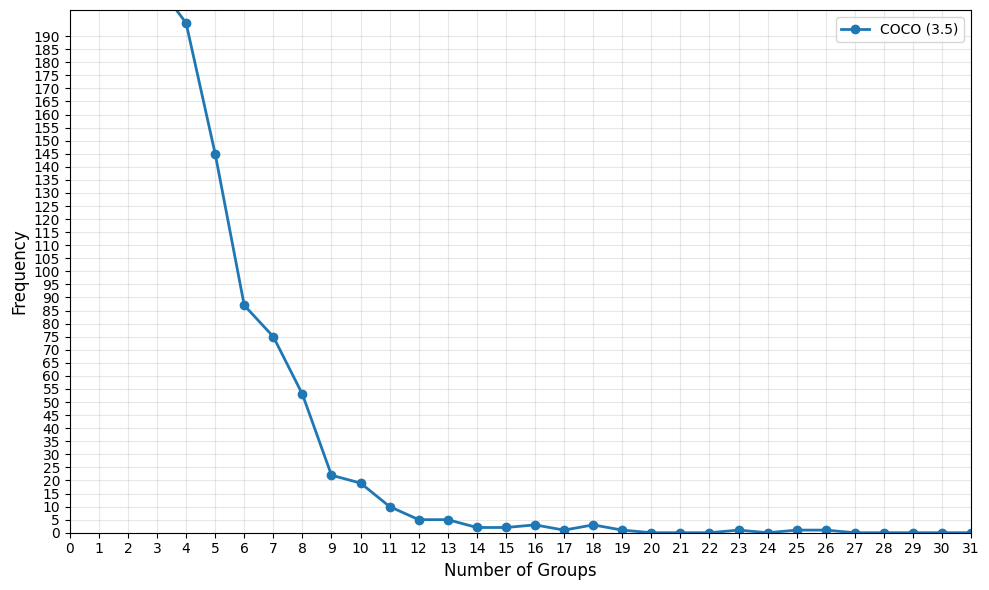

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data (approximate values from the image)
categories = np.arange(0, len(frequencies))

print(np.max(categories))
# COCO (3.5)

ours = frequencies#[17, 20, 19, 12, 10, 8, 6, 5, 4, 3, 3, 2, 2, 2, 2]

# PASCAL VOC (1.4)
# pascal = [70, 22, 8, 3, 2, 1, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

# ImageNet (1.7)
# imagenet = [62, 20, 8, 4, 2, 1.5, 1, 1, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

# SUN (9.8)
# sun = [0.5, 1, 3, 5, 7, 9, 9, 8, 7, 6, 5, 4, 3, 2, 2]

# Create the plot
plt.figure(figsize=(10, 6))

# Plot each line
plt.plot(categories, ours, marker='o', label='COCO (3.5)', linewidth=2, markersize=6)
#plt.plot(categories, pascal, marker='o', label='PASCAL VOC (1.4)', linewidth=2, markersize=6)
#plt.plot(categories, imagenet, marker='s', label='ImageNet (1.7)', linewidth=2, markersize=6)
#plt.plot(categories, sun, marker='^', label='SUN (9.8)', linewidth=2, markersize=6)

# Customize the plot
plt.xlabel('Number of Groups', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(categories)
plt.yticks(np.arange(0, 191, 5))
plt.ylim(0, 200)
plt.xlim(0, max_tam+5)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)

# Format y-axis as percentages
# ax = plt.gca()
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.tight_layout()
plt.show()

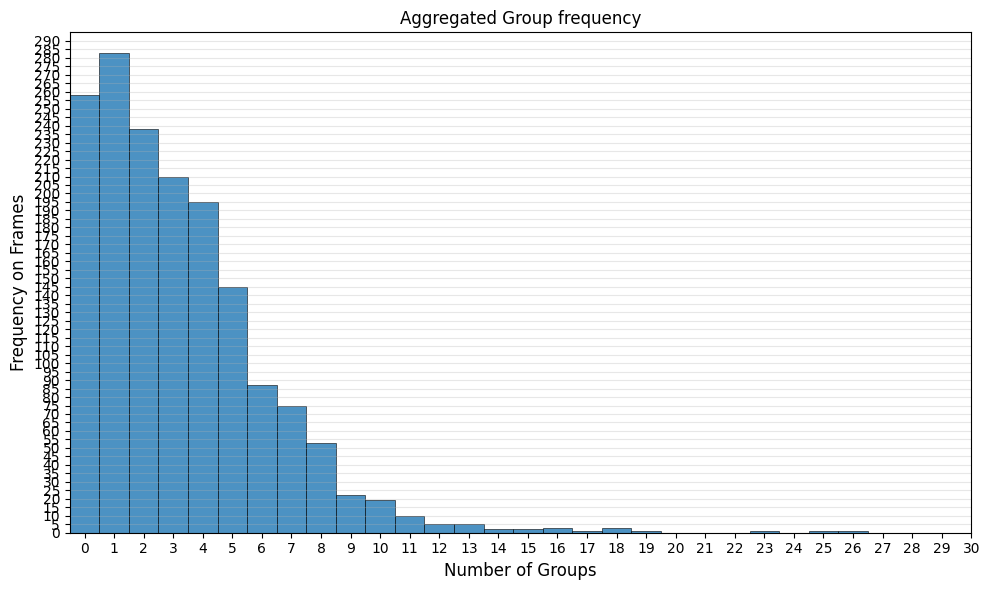

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data (approximate values from the image)
categories = np.arange(0,len(frequencies))

# COCO (3.5)
ours = frequencies
# Create the plot
plt.figure(figsize=(10, 6))

# Plot bar chart
plt.bar(categories, ours, width=1.0, alpha=0.8, edgecolor='black', linewidth=0.5)

# Customize the plot
plt.xlabel('Number of Groups', fontsize=12)
plt.ylabel('Frequency on Frames', fontsize=12)
plt.title('Aggregated Group frequency', fontsize=12)
plt.xticks(categories)
plt.yticks(np.arange(0, 295, 5))
plt.ylim(0, 295)
plt.xlim(-0.5, 30)
plt.grid(True, alpha=0.3, axis='y')
#plt.legend(loc='upper right', fontsize=10)

# Format y-axis as percentages
ax = plt.gca()
#ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.tight_layout()
plt.savefig('fig_annotations/Aggregated_Group_Frequency.pdf', format='pdf', bbox_inches='tight')
plt.show()

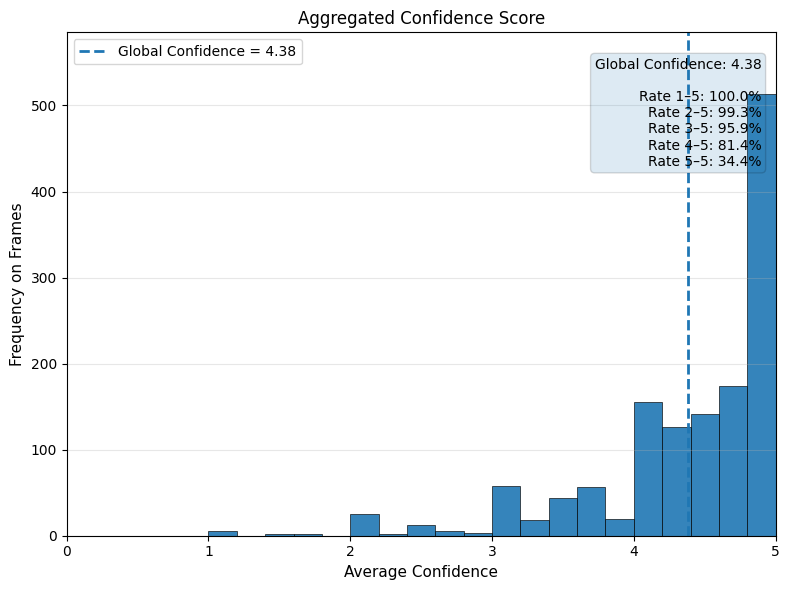

In [11]:
import matplotlib.pyplot as plt
import numpy as np

data = np.array(avg_score)
total = len(data)

# ---- Global confidence score (mean) ----
global_confidence = np.mean(data)

# ---- Cumulative rates ----
rates = {
    "1–5": np.sum((data >= 1) & (data <= 5)) / total,
    "2–5": np.sum((data >= 2) & (data <= 5)) / total,
    "3–5": np.sum((data >= 3) & (data <= 5)) / total,
    "4–5": np.sum((data >= 4) & (data <= 5)) / total,
    "5–5": np.sum(data == 5) / total,
}

# ---- Plot ----
plt.figure(figsize=(8, 6))

plt.hist(
    data,
    bins=20,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.9
)

# Global confidence vertical line
plt.axvline(
    global_confidence,
    linestyle='--',
    linewidth=2,
    label=f'Global Confidence = {global_confidence:.2f}'
)

plt.xlabel('Average Confidence', fontsize=11)
plt.ylabel('Frequency on Frames', fontsize=11)
plt.title('Aggregated Confidence Score', fontsize=12)

plt.xlim(0, 5)
plt.ylim(0, 585)
plt.grid(True, alpha=0.3, axis='y')

# ---- Annotation text ----
text = (
    f"Global Confidence: {global_confidence:.2f}\n\n" +
    "\n".join([f"Rate {k}: {v*100:.1f}%" for k, v in rates.items()])
)

plt.text(
    0.98, 0.95, text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.15)
)

plt.legend()
plt.tight_layout()
plt.savefig('fig_annotations/Aggregated_Confidence_Score.pdf', format='pdf', bbox_inches='tight')
plt.show()


# LAST FIGURE

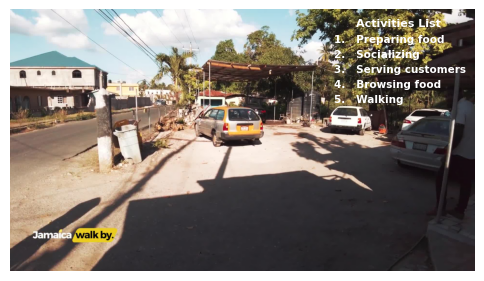

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from matplotlib.lines import Line2D

# Load image
image = cv2.imread('videos/clip_0001/00001.jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(image)

# Left column: numbers
confidence_values = [1, 2, 3, 4, 5]
left_labels = [f"{i+1}." for i in range(len(confidence_values))]

# Right column: your activity names
right_labels = ["Preparing food", "Socializing", "Serving customers", "Browsing food", "Walking", "Shopping", "Selling food", "Eating"]

# Combine into rows:  "1.  Walking", etc.
combined_labels = [f"{left:<3}  {right}" for left, right in zip(left_labels, right_labels)]

# Invisible handles
empty_handles = [Line2D([], [], linestyle="none") for _ in combined_labels]

legend = ax.legend(
    empty_handles,
    combined_labels,
    title="Activities List",
    loc="upper right",
    frameon=False,
    handlelength=0,
    handletextpad=0.2,
    prop={'size': 7.5, 'weight': 'bold'},
    title_fontsize=8
)

# Style text
for text in legend.get_texts():
    text.set_color("white")

legend.get_title().set_color("white")
legend.get_title().set_fontweight("bold")

ax.axis("off")
plt.savefig("fig_annotations/sample_activities_list.pdf", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()